In [56]:
!pip install torch torchvision
!pip install numpy pandas matplotlib tqdm pillow --quiet
%pip install ipywidgets


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import os
import uuid
import shutil
import json
import copy
from datetime import datetime
import zipfile
import io
import requests
import random

In [58]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.pyplot import imshow
from tqdm import tqdm
from ipywidgets import IntProgress
import time 

In [59]:
import torch
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader,random_split
from torch.optim import lr_scheduler
from torchvision import transforms
import torch.nn as nn
torch.manual_seed(0)
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [60]:
def plot_stuff(COST, ACC):
    """
    Plots training cost (loss) and validation accuracy on the same figure using two y-axes.
    
    Parameters:
    COST (list or array): Total training loss per iteration (or epoch)
    ACC (list or array): Validation accuracy per iteration (or epoch)
    """
    
    # Create a new figure and a primary axis (ax1)
    fig, ax1 = plt.subplots()
    
    # Plot training loss on the primary y-axis (left)
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('Iteration', color=color)            # Label for x-axis
    ax1.set_ylabel('Total Loss', color=color)           # Label for y-axis (left)
    ax1.tick_params(axis='y', labelcolor=color)         # Set y-axis tick color

    # Create a secondary y-axis (ax2) sharing the same x-axis
    ax2 = ax1.twinx()
    
    # Plot validation accuracy on the secondary y-axis (right)
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy', color=color)             # Label for y-axis (right)
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Adjust layout to prevent y-label clipping
    fig.tight_layout()
    
    # Display the combined plot
    plt.show()


In [61]:
def imshow_(inp, title=None):
    """
    Displays a tensor image after reversing normalization.
    
    Parameters:
    - inp (Tensor): Image tensor of shape [C, H, W], usually normalized.
    - title (str, optional): Title for the image display.
    """
    # Convert from [C, H, W] to [H, W, C] and to NumPy array
    inp = inp.permute(1, 2, 0).numpy()
    print("Image shape:", inp.shape)

    # Undo normalization (ImageNet mean and std)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean

    # Clip values to [0, 1] range for display
    inp = np.clip(inp, 0, 1)

    # Display image
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # Short pause for GUI update
    plt.show()


In [62]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("the device type is", device)


the device type is cpu


In [63]:
# URL of the ZIP file
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ExisQFol3hUHktTjm6a51w/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z.zip"

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Open the zip file from the downloaded content
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall("not_stopandstop")  # Extract to a target folder
    print("Download and extraction complete.")
else:
    print("Failed to download file:", response.status_code)


Download and extraction complete.


In [64]:
#sets path
source_dir = "not_stopandstop/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z"  # folder containing images and annotation file
annotations_file = os.path.join(source_dir, "_annotations.json")  # update name if needed

In [65]:
# Load annotations
with open(annotations_file, "r") as f:
    annotations = json.load(f)

In [66]:
# Parameters
train_ratio = 0.9
output_dir = "dataset"  # Final output root directory


In [67]:
# Prepare label -> image list
label_to_images = {}

for filename, entry in annotations["annotations"].items():
    label = entry[0]["label"]
    label_to_images.setdefault(label, []).append(filename)

In [68]:
# Shuffle and split each class into training and validation sets
for label, image_list in label_to_images.items():
    random.shuffle(image_list)  # Shuffle the list of images to randomize the split
    
    # Calculate the number of training images (e.g., 90% of total)
    train_cutoff = int(len(image_list) * train_ratio)
    
    # Split the image list into training and validation sets
    train_images = image_list[:train_cutoff]
    val_images = image_list[train_cutoff:]

    # Loop over both splits: 'train' and 'val'
    for split, split_images in zip(["train", "val"], [train_images, val_images]):
        
        # Create the output directory for the current split and label
        # Example: dataset/train/not_stop or dataset/val/stop
        out_path = os.path.join(output_dir, split, label)
        os.makedirs(out_path, exist_ok=True)  # Create the directory if it doesn't exist

        # Copy each image from the source directory to the appropriate split folder
        for img_name in split_images:
            src = os.path.join(source_dir, img_name)  # Full path to the source image
            dst = os.path.join(out_path, img_name)    # Destination path
            shutil.copy2(src, dst)  # Copy the image (preserves metadata)

# Print completion message once all images are copied
print("Train/Val split complete.")


Train/Val split complete.


## Exercise 1: Apply Image Transformations


In [69]:
# Define a series of transformations to apply to each image
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224×224 pixels to ensure consistent input dimensions.
    transforms.ToTensor(),          # Convert image to PyTorch tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # Mean for ImageNet pretrained models
        std=[0.229, 0.224, 0.225]   # Std deviation for ImageNet pretrained models
    )
])


## Exercise 2: Load Datasets with Transformations


In [70]:
# Load datasets from the respective folders
train_dataset = ImageFolder(root="dataset/train", transform=transform)
val_dataset = ImageFolder(root="dataset/val", transform=transform)

print("Training classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))


Training classes: ['not_stop', 'stop']
Number of training images: 196
Number of validation images: 39


## Exercise 3: Visualize Samples from the Validation Set


Image shape: (224, 224, 3)


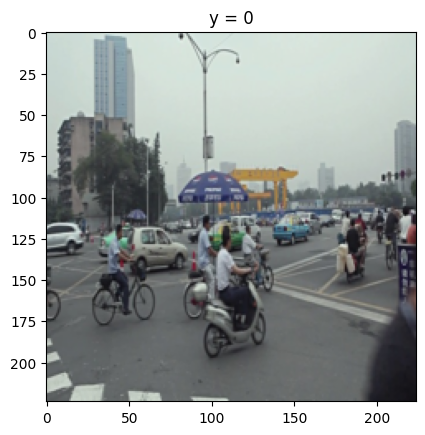

Image shape: (224, 224, 3)


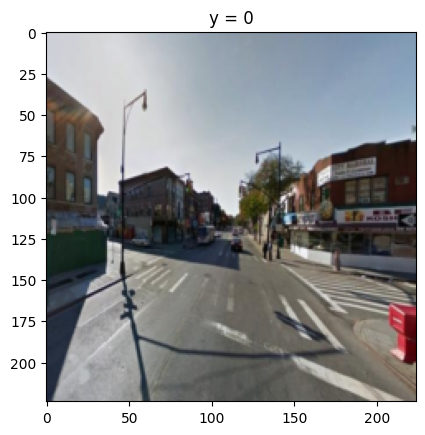

Image shape: (224, 224, 3)


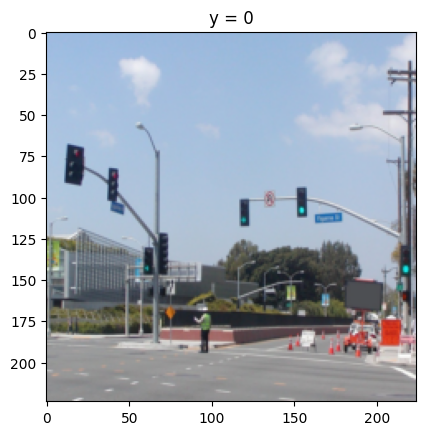

In [71]:
# Loop through the validation dataset and display the first 3 images
i = 0
for x, y in val_dataset:
    imshow_(x, f"y = {y}")
    i += 1
    if i == 3:
        break


## Exercise 4: Reflect on Your Dataset and Transformations


## Exercise 5: Epochs and Batch Size


In [72]:
# Set the number of epochs and batch size
n_epochs = 10
batch_size = 32


## Exercise 6: Configure Learning Rate and Momentum


In [73]:
# Set optimizer hyperparameters
learning_rate = 0.000001
momentum = 0.9


## Exercise 7: Learning Rate Scheduler – Understanding and Setup


In [74]:
# Enable learning rate scheduling
lr_scheduler = True
base_lr = 0.001
max_lr = 0.01


## Exercise 8: Analyze Training Configuration


## Exercise 9: Load a Pretrained Model


In [75]:
# Set the parameter pretrained to true.
model = models.resnet18(pretrained=True)


## Exercise 10: Freeze Feature Extractor Layers


In [76]:
# Freeze all the parameters to prevent updates during training
for param in model.parameters():
    param.requires_grad = False


## Exercise 11: Determine the Number of Classes


In [77]:
# Find number of classes from the dataset
n_classes = len(train_dataset.classes)
print(n_classes)


2


## Exercise 12: Replace the Output Layer


In [78]:
# Replace the output layer to match the number of classes
model.fc = nn.Linear(512, n_classes)


In [79]:
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Exercise 13: Define the Loss Function


In [80]:
# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()


## Exercise 14: Create Data Loaders


In [81]:
# Create data loaders for training and validation
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=1)


## Exercise 15: Set Up the Optimizer


In [82]:
# Initialize the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)


## Exercise 16: Configure a Learning Rate Scheduler


In [83]:
# Optional: use learning rate scheduler
if lr_scheduler:
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=base_lr,
        max_lr=max_lr,
        step_size_up=5,
        mode="triangular2"
    )
else:
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=1.0)


## Exercise 17: Implement and Analyze the Training Loop


In [84]:
def train_model(model, train_loader, validation_loader, criterion, optimizer, n_epochs, print_=True):
    loss_list = []        # Store average training loss per epoch
    accuracy_list = []    # Store validation accuracy per epoch
    correct = 0

    n_test = len(val_dataset)
    accuracy_best = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    print("The first epoch should take several minutes")

    for epoch in tqdm(range(n_epochs)):
        loss_sublist = []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            model.train()   # Set model to training mode

            z = model(x)
            loss = criterion(z, y)
            loss_sublist.append(loss.item())

            loss.backward()        # Backpropagation
            optimizer.step()       # Update weights
            optimizer.zero_grad()  # Reset gradients

        print(f"Epoch {epoch + 1} done")

        # Step learning rate scheduler (if used)
        scheduler.step()

        loss_list.append(np.mean(loss_sublist))

        # Validation
        correct = 0
        model.eval()
        with torch.no_grad():
            for x_test, y_test in validation_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                z = model(x_test)
                _, yhat = torch.max(z.data, 1)
                correct += (yhat == y_test).sum().item()

        accuracy = correct / n_test
        accuracy_list.append(accuracy)

        if accuracy > accuracy_best:
            accuracy_best = accuracy
            best_model_wts = copy.deepcopy(model.state_dict())

        if print_:
            print("Learning rate:", optimizer.param_groups[0]['lr'])
            print(f"Validation loss (epoch {epoch + 1}): {np.mean(loss_sublist):.4f}")
            print(f"Validation accuracy (epoch {epoch + 1}): {accuracy:.4f}")

    model.load_state_dict(best_model_wts)
    return accuracy_list, loss_list, model


## Exercise 18: Reflection


In [85]:
# Start time tracking
start_datetime = datetime.now()
start_time = time.time()

# Train the model
accuracy_list, loss_list, model = train_model(
    model, train_loader, validation_loader, criterion, optimizer, n_epochs=n_epochs
)

# End time tracking
end_datetime = datetime.now()
elapsed_time = time.time() - start_time

# Print results
print("Training completed.")
print(f"Start Time     : {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End Time       : {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Elapsed Time   : {elapsed_time:.2f} seconds")


The first epoch should take several minutes


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 done


 10%|█         | 1/10 [00:04<00:36,  4.03s/it]

Learning rate: 0.002800000000000002
Validation loss (epoch 1): 0.6589
Validation accuracy (epoch 1): 0.7179
Epoch 2 done


...

Learning rate: 0.0046
Validation loss (epoch 8): 0.1061
Validation accuracy (epoch 8): 1.0000
Epoch 9 done


 90%|█████████ | 9/10 [00:29<00:03,  3.16s/it]

Learning rate: 0.002800000000000002
Validation loss (epoch 9): 0.1336
Validation accuracy (epoch 9): 1.0000
Epoch 10 done


100%|██████████| 10/10 [00:32<00:00,  3.26s/it]

Learning rate: 0.001
Validation loss (epoch 10): 0.1778
Validation accuracy (epoch 10): 1.0000
Training completed.
Start Time     : 2026-05-08 22:30:37
End Time       : 2026-05-08 22:31:10
Elapsed Time   : 32.59 seconds


In [86]:
# Save the model to model.pt
torch.save(model.state_dict(), 'model.pt')

## Exercise 19: Plot Training Loss and Validation Accuracy


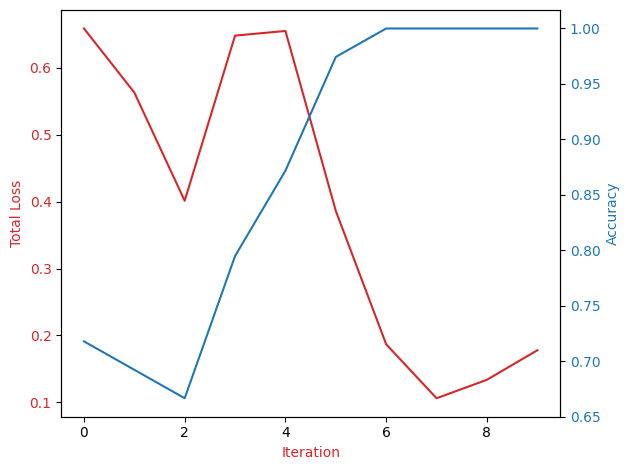

In [87]:
# Use the stored training loss and validation accuracy to plot learning curves
plot_stuff(loss_list, accuracy_list)


## Exercise 20: Interpret the Learning Curves


In [88]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ko-rMe71oPApYpUj2urgFQ/stop-1.jpeg"
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/2oSHTMfHikZvnhKypHO9Uw/stop-2.jpeg"
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/6GVQqlNsZ83-me4L9DzAIg/not-stop-1.jpeg"
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/47aCgskKGqJTYmIkvV6_mA/not-stop-2.jpeg"

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


## Exercise 21: Load a Trained Model for Inference


In [89]:
# Define class labels used during training
class_names = ['not_stop', 'stop']

# Load the same pretrained architecture used during training
model = models.resnet18(pretrained=False)

# Replace the fully connected layer to match number of output classes
model.fc = torch.nn.Linear(model.fc.in_features, 2)

# Load trained model weights
model.load_state_dict(torch.load("model.pt", map_location=torch.device('cpu')))

# Set the model to evaluation mode
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Exercise 22: Preprocess an Image for Prediction


In [90]:
# Define the same image transformations used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Resize image
    transforms.ToTensor(),               # Convert PIL image to tensor
    transforms.Normalize([0.485, 0.456, 0.406],   # Normalize using ImageNet stats
                         [0.229, 0.224, 0.225])
])


## Exercise 23:Load and convert the image


In [91]:
from PIL import Image
import os

# List all image files in this folder and subfolders
image_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Images found:")
for img in image_files:
    print(img)

# Use the first image found
image_path = image_files[0]

image = Image.open(image_path).convert("RGB")

# Apply transformations and add batch dimension
input_tensor = transform(image).unsqueeze(0)

print("Using:", image_path)
print(input_tensor.shape)

Images found:
.\dataset\train\not_stop\00225513-2c14-4250-ae63-5b5273be4716.jpg
.\dataset\train\not_stop\05702c1f-c516-415b-8476-fd01a08fef94.jpg
.\dataset\train\not_stop\05ed98bf-7792-4628-bc25-94ab5aaa4b64.jpg
.\dataset\train\not_stop\07170b9e-efa0-477e-8dde-885246e8f831.jpg
.\dataset\train\not_stop\0e5a60c3-ca8c-4b32-b5bb-15375c732e0a.jpg
.\dataset\train\not_stop\0f1c3522-55f3-4f45-9242-c04f480d6df5.jpg
.\dataset\train\not_stop\0faf9e9e-1ce2-4047-aa10-aa4ba0d5c17d.jpg
.\dataset\train\not_stop\0fdd83be-a5bc-45aa-a340-d5b738302a3d.jpg
.\dataset\train\not_stop\0ffc76d4-47c0-4648-8dd3-6d24e46157fa.jpg
.\dataset\train\not_stop\10e82e30-8cad-4a8d-b783-bb2075a2fb58.jpg
.\dataset\train\not_stop\170261d8-c717-45ae-9c0e-f17fb542cc78.jpg
.\dataset\train\not_stop\17302b6f-2390-4f8a-9b94-f9e1f5a38d66.jpg
.\dataset\train\not_stop\21377bec-8fea-4bcf-a9a5-bccd6c1bc476.jpg
.\dataset\train\not_stop\2641e334-0c8e-490d-af8c-863152d1c665.jpg
.\dataset\train\not_stop\27620245-135b-43da-803f-a8a45db265bd.

## Exercise 24:


## Exercise 25: Make a Prediction and Display the Result


The image was classified as: not_stop


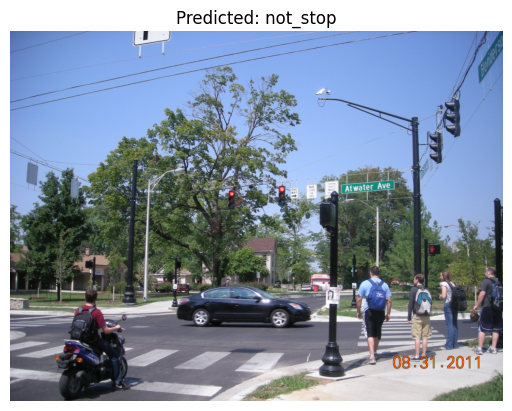

In [92]:
# Perform inference without tracking gradients using no_grad()
with torch.no_grad():
    outputs = model(input_tensor)  # Forward pass
    predicted_class = torch.argmax(outputs, dim=1).item()  # Get predicted class index using argmax

# Display result
print(f"The image was classified as: {class_names[predicted_class]}")

# Visualize the image with the predicted label
plt.imshow(image)  # Original image (PIL format)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()
